In [3]:
pip install --upgrade battery-data-standard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.2/106.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 16.9 MB/s eta 0:00:00


## Quick Start: Convert A Mixed Arbin Workbook

This workbook contains both time-series data and EIS data:

- time-series sheet: `Channel_4_1`
- EIS sheet: `ACIM_Chan4`

The fastest workflow is to convert each sheet explicitly.

In [21]:
from pathlib import Path
import battery_data_standard as bds
import polars as pl

input_path = Path("INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.xlsx")
output_dir = Path("bds_outputs") / "eis_soc20_w8_channel_4"
output_dir.mkdir(parents=True, exist_ok=True)

time_sheet = "Channel_4_1"
eis_sheet = "ACIM_Chan4"

time_csv = output_dir / "channel_4_1.bds.csv"
eis_csv = output_dir / "acim_chan4.eis.csv"

time_report = bds.convert(
    input_path,
    time_csv,
    cycler="arbin",
    sheet=time_sheet,
    current_sign="preserve",
    report_path="auto",
)

eis_report = bds.convert_eis(
    input_path,
    eis_csv,
    sheet=eis_sheet,
    format="csv",
)

print("BDS version:", bds.__version__)
print("Time-series CSV:", time_csv)
print("Time-series valid:", time_report.validation.valid)
print("Time-series rows:", time_report.rows)
print("EIS CSV:", eis_csv)
print("EIS valid:", eis_report.valid)
print("EIS rows:", eis_report.rows)

BDS version: 0.2.2
Time-series CSV: bds_outputs/eis_soc20_w8_channel_4/channel_4_1.bds.csv
Time-series valid: True
Time-series rows: 323
EIS CSV: bds_outputs/eis_soc20_w8_channel_4/acim_chan4.eis.csv
EIS valid: True
EIS rows: 19




---



---



# BDS 0.2.2 Mixed Arbin Workbook Walkthrough

This notebook runs `battery-data-standard` on one real Arbin workbook that contains both time-series and EIS worksheets:

`INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.xlsx`

- Time-series sheet: `Channel_4_1`
- EIS sheet: `ACIM_Chan4`

Dataset citation:

Pozzato, G., Allam, A., & Onori, S. (2023, March 1). *Lithium-ion battery aging dataset based on electric vehicle real-driving profiles*. Retrieved from osf.io/qsabn.

It demonstrates sheet inspection, time-series diagnostics, EIS reading, validation, conversion, report writing, and CLI parity.

## 1. Environment And Input File

In [7]:
from pathlib import Path
import json
import subprocess
import sys

# load data
repo_root = Path("/content")
input_path = repo_root / "INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.xlsx"
output_dir = repo_root / "examples" / "output" / "eis_soc20_w8_channel_4"
output_dir.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("Input exists:", input_path.exists())
print("Input:", input_path)
print("Output directory:", output_dir)
assert input_path.exists(), f"Missing input file: {input_path}"

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Input exists: True
Input: /content/INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.xlsx
Output directory: /content/examples/output/eis_soc20_w8_channel_4


## 2. Use The Latest BDS Package

In [4]:
import battery_data_standard as bds

print("BDS version:", bds.__version__)
assert bds.__version__ >= "0.2.1", "This notebook expects battery-data-standard 0.2.1 or newer."

BDS version: 0.2.2


## 3. Inspect Workbook Sheets

Before using BDS, inspect the workbook sheets so the selected EIS sheet is visible.

In [8]:
import pandas as pd

excel_file = pd.ExcelFile(input_path)
sheets = excel_file.sheet_names

print("Sheet count:", len(sheets))
for index, sheet in enumerate(sheets):
    print(f"{index}: {sheet}")

Sheet count: 4
0: Global_Info
1: RawData_4_1
2: ACIM_Chan4
3: Channel_4_1


## 4. Detect Data Kind

`detect_kind()` identifies whether the file should be routed as time-series, EIS, unsupported helper content, or unknown.

In [9]:
kind = bds.detect_kind(input_path)

print("Kind:", kind.kind)
print("Confidence:", kind.confidence)
print("Reason:", kind.reason)
print("Path:", kind.path)

Kind: timeseries
Confidence: 0.8
Reason: time, voltage, and current-like columns detected
Path: /content/INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.xlsx


## 5. Run Explain Diagnostics

`bds.explain()` is the 0.2.2 single-file diagnostic entry point. For an EIS workbook, it should identify the EIS route and return a structured diagnostic payload without writing converted data.

In [10]:
explain_report = bds.explain(input_path)

print(explain_report.to_text())

payload = explain_report.to_dict()
print("\nPayload keys:")
for key in payload:
    print("-", key)

BDS explain
Input: /content/INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.xlsx
Status: ok
Data kind: timeseries (0.8)
Adapter: arbin (0.8)
Sheet: Channel_4_1
Current sign: charge-positive
Current sign evidence: raw current mapped without explicit charge/discharge sign evidence
Validation valid: True
Time sampling: no-gaps
Warnings:
- Would shift test_time_s to start at 0.
Validation issues:
- missing-optional-column: Optional column record_index is absent.
- missing-optional-column: Optional column temperature_t1_deg_c is absent.
Column mapping:
- Test_Time(s) (s) -> test_time_s -> Test Time (s) [numeric]
- Voltage(V) (V) -> voltage_v -> Voltage (V) [numeric]
- Current(A) (A) -> current_a -> Current (A) [numeric]
- Date_Time -> unix_time_s ->  [parsed UTC timestamp]
- Date_Time -> date_time -> Date Time [string]
- Cycle_Index -> cycle_index -> Cycle Count [integer]
- Step_Index -> step_index -> Step Index [integer]
- Step_Time(s) (s) -> step_time_s -> Step Time (s) [numeric]
- Aux_Tem

## 6. Save Explain Reports

Write JSON, HTML, Excel, and PDF diagnostic reports for review.

In [11]:
report_paths = bds.write_explain_reports(
    explain_report,
    output_dir,
    formats=("json", "html", "xlsx", "pdf"),
    stem="eis_soc20_w8_channel_4_explain",
)

for fmt, path in report_paths.items():
    print(fmt, "->", path)

json -> /content/examples/output/eis_soc20_w8_channel_4/eis_soc20_w8_channel_4_explain.report.json
html -> /content/examples/output/eis_soc20_w8_channel_4/eis_soc20_w8_channel_4_explain.report.html
xlsx -> /content/examples/output/eis_soc20_w8_channel_4/eis_soc20_w8_channel_4_explain.report.xlsx
pdf -> /content/examples/output/eis_soc20_w8_channel_4/eis_soc20_w8_channel_4_explain.report.pdf


## 7. Review The Diagnostic JSON

Read back the JSON report and show the most important routing fields.

In [12]:
json_report_path = Path(report_paths["json"])
diagnostic = json.loads(json_report_path.read_text(encoding="utf-8"))

fields = [
    "status",
    "selected_adapter",
    "confidence",
    "sheet",
    "source_columns",
    "canonical_columns",
    "recommended_next_action",
    "error_type",
    "error",
]

for field in fields:
    print(f"{field}:")
    print(diagnostic.get(field))
    print()

status:
ok

selected_adapter:
arbin

confidence:
0.8

sheet:
Channel_4_1

source_columns:
['Date_Time', 'Test_Time(s)', 'Step_Time(s)', 'Step_Index', 'Cycle_Index', 'Voltage(V)', 'Current(A)', 'Charge_Capacity(Ah)', 'Discharge_Capacity(Ah)', 'Charge_Energy(Wh)', 'Discharge_Energy(Wh)', 'Internal Resistance(Ohm)', 'dV/dt(V/s)', 'Aux_Temperature(¡æ)_1']

canonical_columns:
['test_time_s', 'voltage_v', 'current_a', 'unix_time_s', 'date_time', 'cycle_index', 'step_index', 'step_time_s', 'ambient_temperature_deg_c', 'charge_capacity_ah', 'discharge_capacity_ah', 'charge_energy_wh', 'discharge_energy_wh', 'power_w', 'internal_resistance_ohm']

recommended_next_action:
Convert with bds convert <input> <output> --cycler arbin --report auto.

error_type:
None

error:
None



## 8. Read The EIS Table

For EIS files, use `read_eis()` instead of the ordinary time-series `read()` path.

In [13]:
eis_df = bds.read_eis(input_path)

print("Rows:", eis_df.height)
print("Columns:", eis_df.columns)
eis_df.head(10)

Rows: 19
Columns: ['Frequency_Hz', 'Zre_exp_Ohm', 'Zim_exp_Ohm', '-Zim_exp_Ohm', 'Phase_exp_deg', 'Cycle_ID']


Frequency_Hz,Zre_exp_Ohm,Zim_exp_Ohm,-Zim_exp_Ohm,Phase_exp_deg,Cycle_ID
f64,f64,f64,f64,f64,i64
10019.530273,0.030071,0.034481,-0.034481,48.907551,1
4630.334961,0.025392,0.01735,-0.01735,34.343788,1
2141.204102,0.02381,0.007813,-0.007813,18.166691,1
1000.702026,0.02384,0.002946,-0.002946,7.04386,1
463.598907,0.024399,0.000545,-0.000545,1.280576,1
215.022903,0.0251,-0.000612,0.000612,-1.396321,1
99.734001,0.025871,-0.001185,0.001185,-2.623362,1
45.955879,0.0267,-0.001473,0.001473,-3.158041,1
21.502291,0.027587,-0.001616,0.001616,-3.352693,1


## 9. Validate The EIS Table

`validate_eis()` checks the standardized EIS columns and numeric validity.

In [14]:
eis_validation = bds.validate_eis(eis_df)

print("Valid:", eis_validation.valid)
print("Schema:", eis_validation.schema_version)
print("Rows:", eis_validation.rows)
print("Columns:", eis_validation.columns)

if eis_validation.issues:
    for issue in eis_validation.issues:
        print(issue.to_dict())
else:
    print("No validation issues.")

Valid: True
Schema: eis-2026-05
Rows: 19
Columns: ['Frequency_Hz', 'Zre_exp_Ohm', 'Zim_exp_Ohm', '-Zim_exp_Ohm', 'Phase_exp_deg', 'Cycle_ID']
No validation issues.


## 10. Convert EIS To Standard CSV And Parquet

`convert_eis()` writes the standardized EIS table. CSV is easy to inspect; Parquet is useful for analysis pipelines.

In [15]:
eis_csv = output_dir / "INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.eis.csv"
eis_parquet = output_dir / "INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.eis.parquet"

csv_report = bds.convert_eis(input_path, eis_csv, format="csv")
parquet_report = bds.convert_eis(input_path, eis_parquet, format="parquet")

print("CSV:", eis_csv)
print("CSV valid:", csv_report.valid)
print("Parquet:", eis_parquet)
print("Parquet valid:", parquet_report.valid)

CSV: /content/examples/output/eis_soc20_w8_channel_4/INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.eis.csv
CSV valid: True
Parquet: /content/examples/output/eis_soc20_w8_channel_4/INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.eis.parquet
Parquet valid: True


## 11. Read Back Converted Outputs

Confirm that the written CSV and Parquet files contain the same standardized columns.

In [16]:
import polars as pl

csv_df = pl.read_csv(eis_csv)
parquet_df = pl.read_parquet(eis_parquet)

print("CSV shape:", csv_df.shape)
print("Parquet shape:", parquet_df.shape)
print("Same columns:", csv_df.columns == parquet_df.columns)

csv_df.head(10)

CSV shape: (19, 6)
Parquet shape: (19, 6)
Same columns: True


Frequency_Hz,Zre_exp_Ohm,Zim_exp_Ohm,-Zim_exp_Ohm,Phase_exp_deg,Cycle_ID
f64,f64,f64,f64,f64,i64
10019.530273,0.030071,0.034481,-0.034481,48.907551,1
4630.334961,0.025392,0.01735,-0.01735,34.343788,1
2141.204102,0.02381,0.007813,-0.007813,18.166691,1
1000.702026,0.02384,0.002946,-0.002946,7.04386,1
463.598907,0.024399,0.000545,-0.000545,1.280576,1
215.022903,0.0251,-0.000612,0.000612,-1.396321,1
99.734001,0.025871,-0.001185,0.001185,-2.623362,1
45.955879,0.0267,-0.001473,0.001473,-3.158041,1
21.502291,0.027587,-0.001616,0.001616,-3.352693,1


## 12. Quick EIS Summary

Summarize the standardized impedance table.

In [17]:
summary = {
    "rows": eis_df.height,
    "frequency_min_hz": eis_df["Frequency_Hz"].min(),
    "frequency_max_hz": eis_df["Frequency_Hz"].max(),
    "zre_min_ohm": eis_df["Zre_exp_Ohm"].min(),
    "zre_max_ohm": eis_df["Zre_exp_Ohm"].max(),
    "zim_min_ohm": eis_df["Zim_exp_Ohm"].min(),
    "zim_max_ohm": eis_df["Zim_exp_Ohm"].max(),
}

summary

{'rows': 19,
 'frequency_min_hz': 0.010000599548220634,
 'frequency_max_hz': 10019.5302734375,
 'zre_min_ohm': 0.02380961050099037,
 'zre_max_ohm': 0.03527922105150509,
 'zim_min_ohm': -0.009657537129281385,
 'zim_max_ohm': 0.03448069530586855}

## 13. Nyquist Plot

Plot `Zre_exp_Ohm` against `-Zim_exp_Ohm` for a quick visual check.

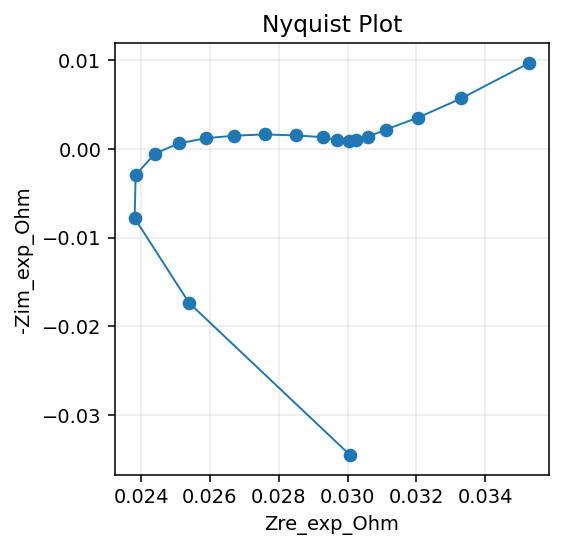

In [18]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is None:
    print("matplotlib is not installed. Install it if a plot is needed.")
else:
    plot_df = eis_df.select(["Zre_exp_Ohm", "Zim_exp_Ohm"]).to_pandas()

    fig, ax = plt.subplots(figsize=(4, 4), dpi=140)
    ax.plot(plot_df["Zre_exp_Ohm"], -plot_df["Zim_exp_Ohm"], marker="o", linewidth=1)
    ax.set_xlabel("Zre_exp_Ohm")
    ax.set_ylabel("-Zim_exp_Ohm")
    ax.set_title("Nyquist Plot")
    ax.grid(True, alpha=0.25)
    plt.show()

## 14. CLI Parity

The same operations are available through the `bds` command line.

In [19]:
cli_json = output_dir / "cli_eis_soc20_w8_channel_4_explain.json"
cli_html = output_dir / "cli_eis_soc20_w8_channel_4_explain.html"
cli_xlsx = output_dir / "cli_eis_soc20_w8_channel_4_explain.xlsx"
cli_pdf = output_dir / "cli_eis_soc20_w8_channel_4_explain.pdf"

cmd = [
    sys.executable,
    "-m",
    "battery_data_standard.cli",
    "explain",
    str(input_path),
    "--json",
    str(cli_json),
    "--html",
    str(cli_html),
    "--xlsx",
    str(cli_xlsx),
    "--pdf",
    str(cli_pdf),
]

run = subprocess.run(cmd, text=True, capture_output=True, check=True)

print(run.stdout[:2000])
print("JSON exists:", cli_json.exists())
print("HTML exists:", cli_html.exists())
print("XLSX exists:", cli_xlsx.exists())
print("PDF exists:", cli_pdf.exists())

{
  "input_path": "/content/INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.xlsx",
  "status": "ok",
  "data_kind": {
    "kind": "timeseries",
    "confidence": 0.8,
    "reason": "time, voltage, and current-like columns detected",
    "path": "/content/INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.xlsx",
    "evidence": {
      "columns": [
        "Date_Time",
        "Test_Time(s)",
        "Step_Time(s)",
        "Step_Index",
        "Cycle_Index",
        "Voltage(V)",
        "Current(A)",
        "Charge_Capacity(Ah)",
        "Discharge_Capacity(Ah)",
        "Charge_Energy(Wh)",
        "Discharge_Energy(Wh)",
        "Internal Resistance(Ohm)",
        "dV/dt(V/s)",
        "Aux_Temperature(\u00a1\u00e6)_1"
      ]
    }
  },
  "detection": {
    "cycler": "arbin",
    "confidence": 0.8,
    "reason": "signature match",
    "candidates": [
      {
        "cycler": "arbin",
        "confidence": 0.8,
        "reason": "signature match"
      },
      {
        "cycler": "re

## 15. Output Inventory

List the generated outputs. These files are written under `examples/output/`, which should stay outside the committed notebook unless intentionally published.

In [20]:
for path in sorted(output_dir.glob("*")):
    print(path.name, path.stat().st_size)

INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.eis.csv 2052
INR21700_M50T_T23_Aging_EIS_SOC20_W8_Channel_4.eis.parquet 2873
cli_eis_soc20_w8_channel_4_explain.html 10614
cli_eis_soc20_w8_channel_4_explain.json 7802
cli_eis_soc20_w8_channel_4_explain.pdf 5576
cli_eis_soc20_w8_channel_4_explain.xlsx 17414
eis_soc20_w8_channel_4_explain.report.html 10614
eis_soc20_w8_channel_4_explain.report.json 7802
eis_soc20_w8_channel_4_explain.report.pdf 5576
eis_soc20_w8_channel_4_explain.report.xlsx 17414
